# Analiza za 9.9.2026, colormaps za EI 2 baths in fixed point T1, T2 check z equivalent T

Za logs + saved files sta fixed_baths.py in phase_map_plots.py

In [ ]:
import sys
from pathlib import Path

import numpy as np
import yaml

ROOT = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths")
CFG = ROOT / "config" / "config_test.yaml"


import EI.ei_unified as eu
from phase_map_plots import plot_maps, scan_maps
from fixed_baths import (
    plot_bz,
    plot_dispersion,
    plot_energy,
    plot_xi,
    solve_state,
    solve_teff,
)
from utils.cosmetics import apply_plt_style
from utils.logger import logger
from utils.plotting_utils import Plotter

apply_plt_style()
pt = Plotter(show=True, close=False)

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

/home/kzeleznikar/IJS-F1/.venv/lib/python3.13/site-packages/sacred/dependencies.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
with CFG.open("r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]
sc = cfg["scan"]
op = cfg["open_system"]
nk = md["nk"]
bp = md["band"]["pars"]

bdm = eu.tb_2d(nk["scan"], **bp)
bdr = eu.tb_2d(nk["reference"], **bp)
p = eu.MFPars(**md["mean_field"])

In [3]:
s0 = eu.solve_eq(bdr, p, **eq["initial"], **eq["solve"])
d0 = max(abs(float(s0.d)), 1.0e-12)
m0 = float(s0.m)
tc = float(eu.critical_temperature(bdr, p, **eq["critical"]))

logger.info("Delta_0 = %.8f", d0)
logger.info("m_0 = %.8f", m0)
logger.info("T_c = %.8f", tc)

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[09:15:26] [INFO    ] Delta_0 = 1.01471982
[09:15:26] [INFO    ] m_0 = -0.95140865
[09:15:26] [INFO    ] T_c = 0.55349851


## Colormaps za razlicne gape

nastavu tudi mu_B = V/2

In [4]:
tg = sc["temperature"]
NT_MAP = tg["nt"]
tn = np.linspace(tg["min_ratio"], tg["max_ratio"], NT_MAP)
ta = tn * tc

mf = md["mean_field"]
v = float(mf["v"])
nf = float(mf["n"])
ga = float(bp["gap"])
aa = float(bp["ta"])
ab = float(bp["tb"])
mu_m = 0.5 * v * nf + 0.5 * (aa + ab) / (aa - ab) * (v * m0 - ga)

In [5]:
z = scan_maps(bdm, p, eq, op, ta, d0, m0, mu_m)

T2:   0%|                         0/20 [00:00<?, ?it/s]

T1:   0%|                         0/20 [00:00<?, ?it/s]

T1:   0%|                         0/19 [00:00<?, ?it/s]

T1:   0%|                         0/18 [00:00<?, ?it/s]

T1:   0%|                         0/17 [00:00<?, ?it/s]

...

T1:   0%|                         0/5 [00:00<?, ?it/s]

T1:   0%|                         0/4 [00:00<?, ?it/s]

T1:   0%|                         0/3 [00:00<?, ?it/s]

T1:   0%|                         0/2 [00:00<?, ?it/s]

T1:   0%|                         0/1 [00:00<?, ?it/s]

Saving maps:   0%|                         0/5 [00:00<?, ?it/s]

findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


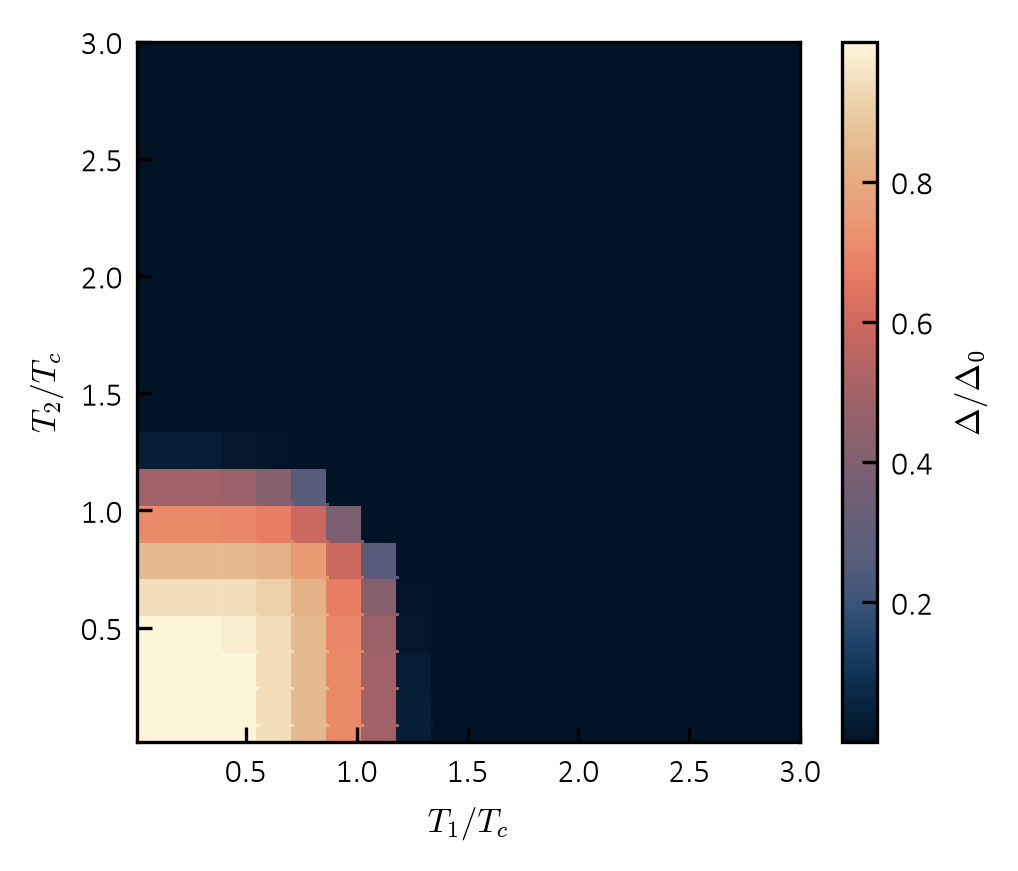

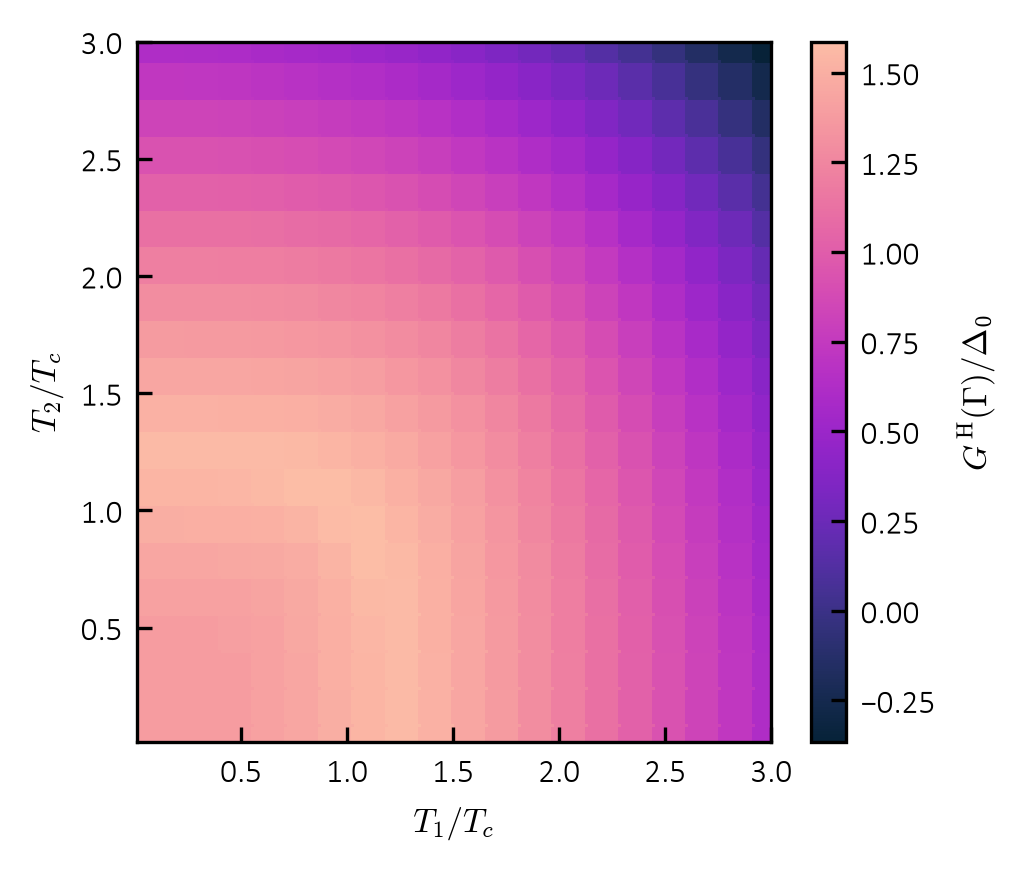

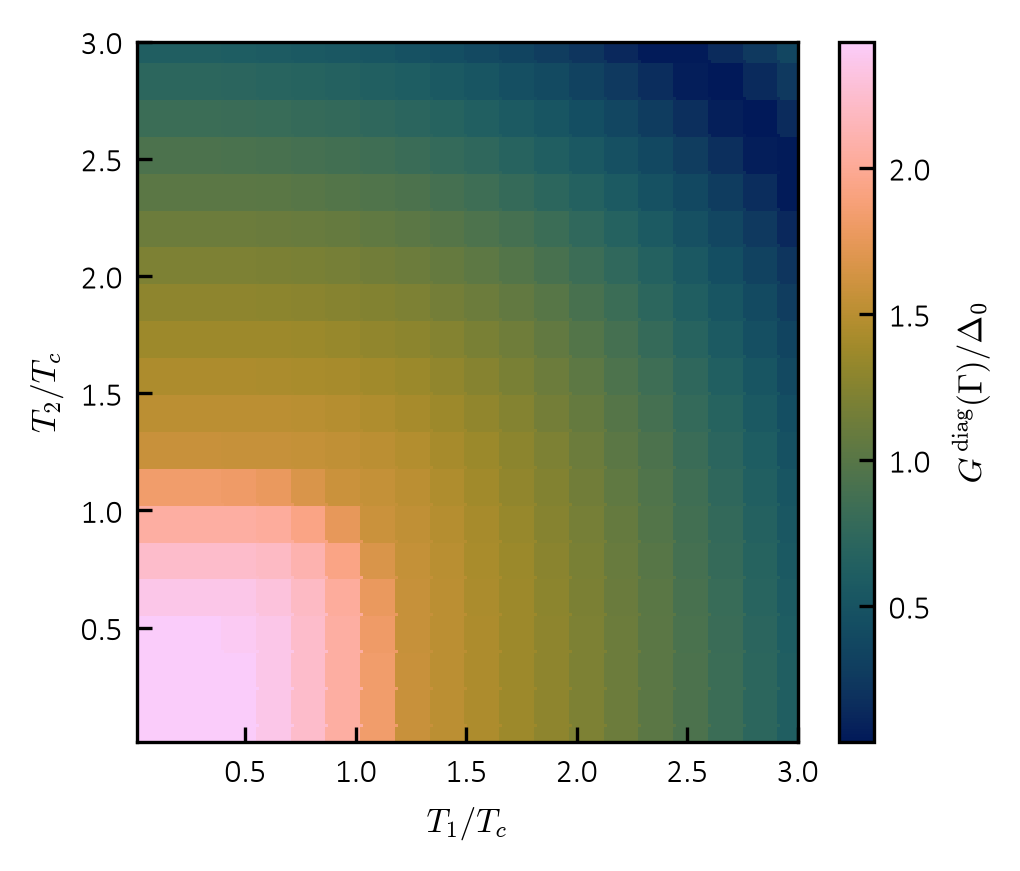

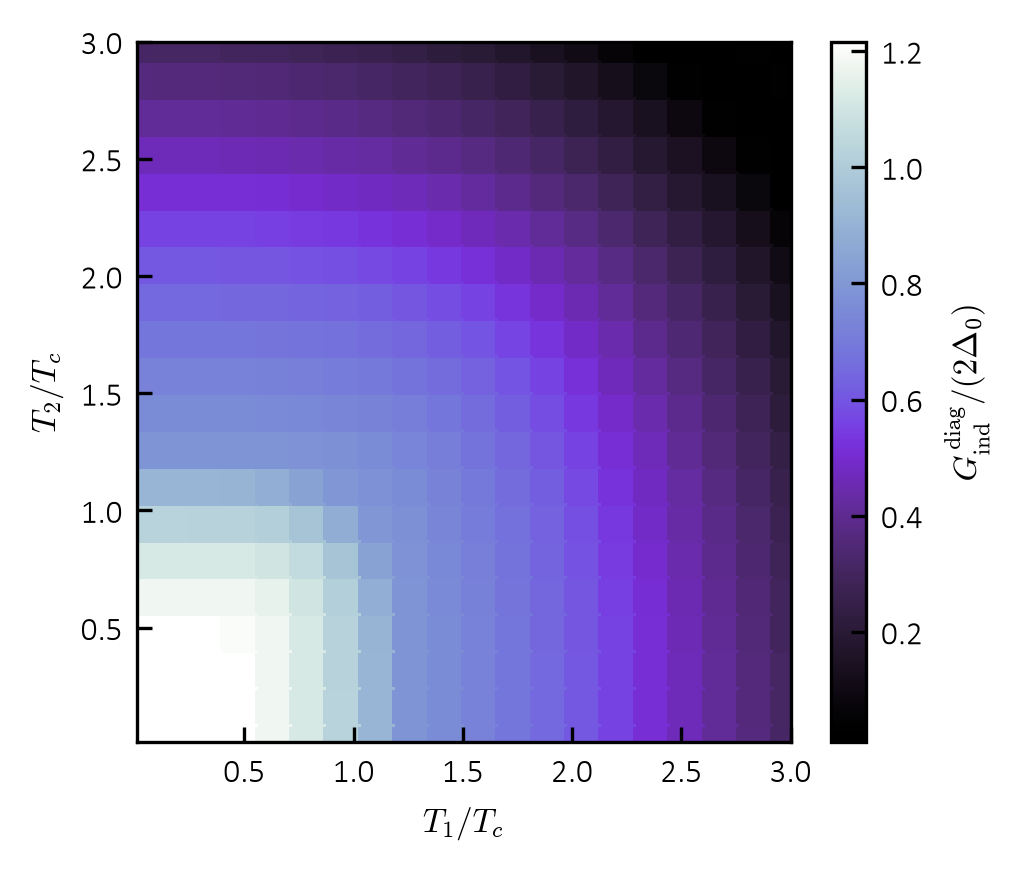

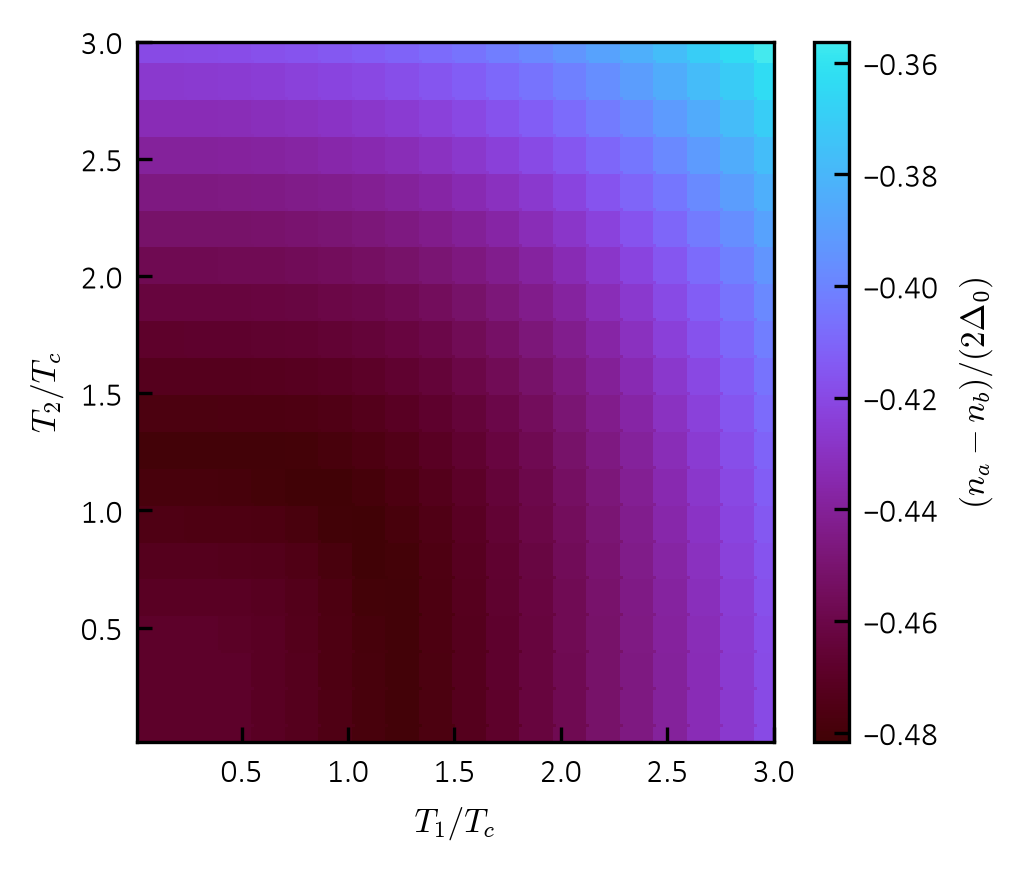

In [6]:
plot_maps(pt, tn, z, d0)

## Koda za eno izbrano tocko + analiza

In [7]:
T1_TC = 500
T2_TC = 0.01
N_CONT = 1

st, bs, t1, t2, mu = solve_state(
    bdr, p, eq, op, T1_TC, T2_TC, tc, d0, m0, N_CONT
)

ep = {
    "dt": 0.05,
    "mix": [0.15, 0.15],
    "tol": 1.0e-6,
    "nmax": 20000,
    "chk": 10,
    "mf": False,
    "prog": True,
    **cfg.get("effective_temperature", {}),
}

sf = solve_teff(bdr, p, bs, st, t1, t2, mu, op, ep)

logger.info("T1/T_c = %.6g, T2/T_c = %.6g", T1_TC, T2_TC)
logger.info("Delta / Delta_0 = %.8f, m = %.8f", st.d / d0, st.m)
logger.info("beta_eff = %.8f, T_eff/T_c = %.8f", sf.beta, sf.t / tc)

Effective temperature:   0%|          | 0/20000 [00:00<?, ?it/s]

[09:15:58] [INFO    ] T1/T_c = 500, T2/T_c = 0.01
[09:15:58] [INFO    ] Delta / Delta_0 = 0.47370664, m = -0.22618890
[09:15:58] [INFO    ] beta_eff = 0.28975171, T_eff/T_c = 6.23530272


findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


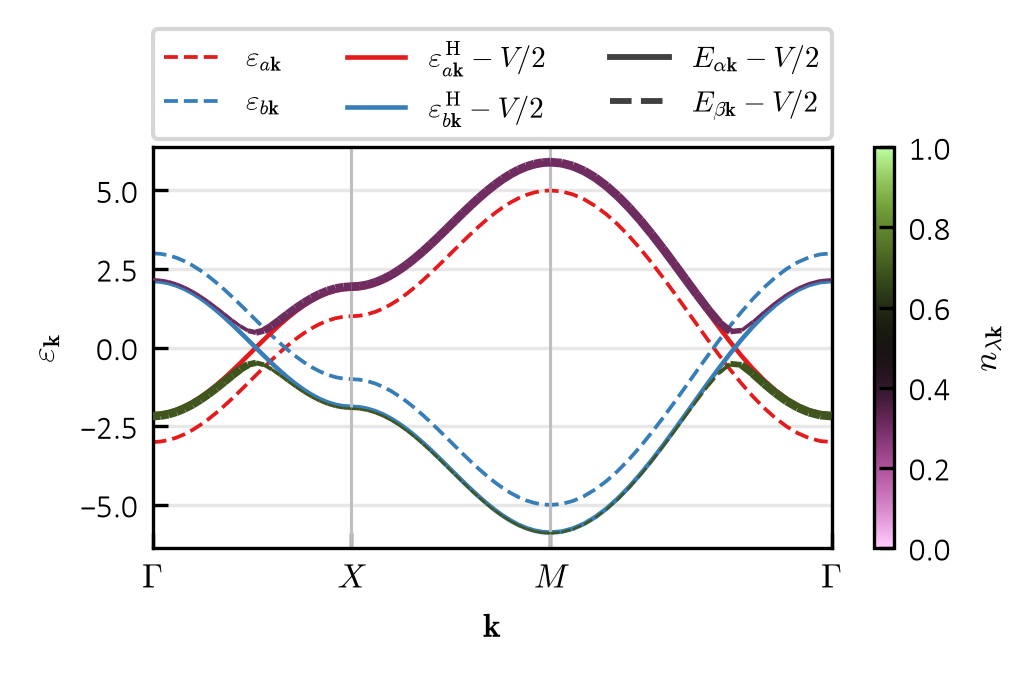

In [8]:
plot_dispersion(pt, bdr, st, mu)

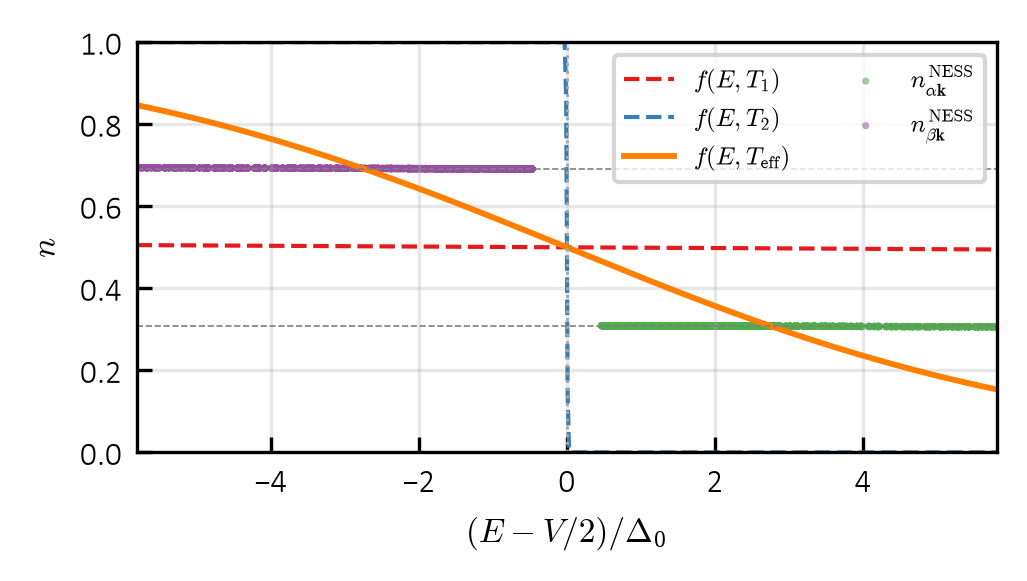

In [11]:
# plot_energy(pt, st, sf, t1, t2, mu, d0)
from utils.cosmetics import SET1_LIST
from utils.plotting_utils import (
    Plotter,
    add_legend,
    color_map,
    format_ax,
)

en = (np.asarray(st.st.e) - mu) / d0
ef = (np.asarray(sf.st.e) - mu) / d0
nn = np.asarray(st.n)
x = np.linspace(min(en.min(), ef.min()), max(en.max(), ef.max()), 600)

def fd(z):
    """FD"""
    return 1.0 / (np.exp(np.clip(z, -500.0, 500.0)) + 1.0)

def fd_t(e, t):
    """FD za T=0"""
    if t <= 0.0:
        return np.where(e < 0.0, 1.0, np.where(e > 0.0, 0.0, 0.5))
    return fd(e / t)


with pt.figure(name="occupations_energy", h=0.68) as q:
    a = q.ax
    a.plot(x, fd_t(x * d0, t1), color=SET1_LIST[0], ls="--", lw=1.0,
            label=r"$f(E,T_1)$")
    a.plot(x, fd_t(x * d0, t2), color=SET1_LIST[1], ls="--", lw=1.0,
            label=r"$f(E,T_2)$")
    a.plot(x, fd(sf.beta * x * d0), color=SET1_LIST[4], lw=1.4,
            label=r"$f(E,T_{\mathrm{eff}})$")
    a.scatter(en[0], nn[0], color=SET1_LIST[2], s=3, alpha=0.55,
                edgecolors="none", label=r"$n_{\alpha\mathbf{k}}^{\mathrm{NESS}}$")
    a.scatter(en[1], nn[1], color=SET1_LIST[3], s=3, alpha=0.55,
                edgecolors="none", label=r"$n_{\beta\mathbf{k}}^{\mathrm{NESS}}$")
    a.axvline(0.0, color="0.65", ls=":", lw=0.7)
    format_ax(a, x=x, xlabel=r"$(E-V/2)/\Delta_0$", ylabel=r"$n$",
                ylim=(0.0, 1.0))
    add_legend(a, ncol=2, fontsize=6, loc=1)
    q.layout((0, 0, 1, 0.84))

    a.plot(x, 0.69093*np.ones_like(x), ls="--", color="gray", lw=0.4)
    a.plot(x, 0.30901*np.ones_like(x), ls="--", color="gray", lw=0.4)


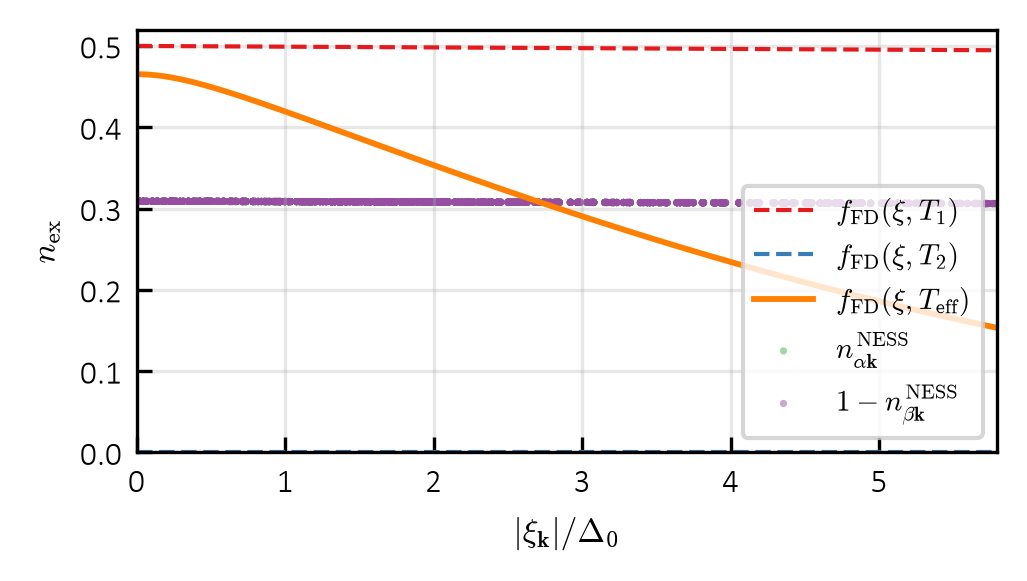

In [10]:
plot_xi(pt, bdr, p, eq, st, sf, t1, t2, d0)

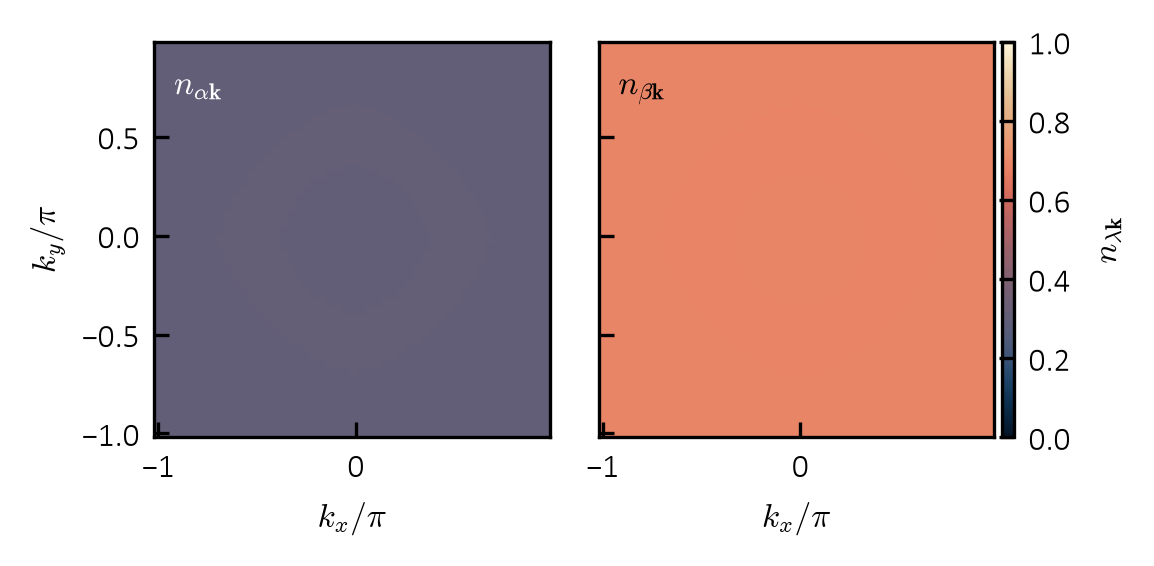

In [12]:
plot_bz(pt, bdr, st)

In [83]:
import EI.ei_jax as ej
import EI.eff_T as et

from utils.logger import tqdm_bar
from utils.cosmetics import SET1_LIST

# Temperature sweep
t2n = 0.02
t1n = np.linspace(t2n, 100.0, 100)

t2 = t2n * tc
mu = 0.5 * float(md["mean_field"]["v"])

# Bath parameters
bc = op["bath"]
bp = {
    **bc["pars"],
    "rate": getattr(ej, bc["rate"]),
    "mu": mu,
}

# Initial equilibrium state at T2
es = {**eq["solve"], "prog": False}
se = eu.solve_eq(
    bdm, p, t=t2,
    d=max(d0, 1.0e-8),
    m=m0,
    **es,
)

n = se.n.copy()
d = se.d
m = se.m
ds = max(0.02 * d0, 1.0e-3)

# Effective-temperature solver parameters
ep = {
    "dt": 0.05,
    "mix": (0.15, 0.15),
    "tol": 1.0e-7,
    "nmax": 10000,
    "chk": 10,
    "mf": False,
    **cfg.get("effective_temperature", {}),
}
ep["prog"] = False
ep.setdefault("mode", op["solve"].get("mode", "block"))
ep.setdefault("block", op["solve"].get("block", 512))

te = np.full(t1n.size, np.nan)
da = np.full(t1n.size, np.nan)
ok = np.zeros(t1n.size, dtype=bool)

be = 1.0 / t2

bh = []

for i, r1 in tqdm_bar(
    enumerate(t1n),
    total=t1n.size,
    desc="T1 sweep",
):
    t1 = r1 * tc

    bs = (
        ej.gam_db(t=t1, name="bath 1", **bp),
        ej.gam_db(t=t2, name="bath 2", **bp),
    )

    so = ej.solve_open(
        bdm, p, n, bs,
        d=d, m=m,
        **op["solve"],
    )

    sf = et.solve_eff(
        bdm, p, bs,
        beta0=be,
        d=so.d,
        m=so.m,
        mu=mu,
        **ep,
    )

    ht = np.asarray(sf.hist["it"]) * ep["dt"]
    hb = np.asarray(sf.hist["beta"])
    bh.append((ht, hb))

    te[i] = sf.t / tc
    da[i] = abs(so.d) / d0
    ok[i] = so.ok and sf.ok

    n = so.n.copy()
    d = max(abs(so.d), ds)
    m = so.m
    be = sf.beta

T1 sweep:   0%|                         0/100 [00:00<?, ?it/s]

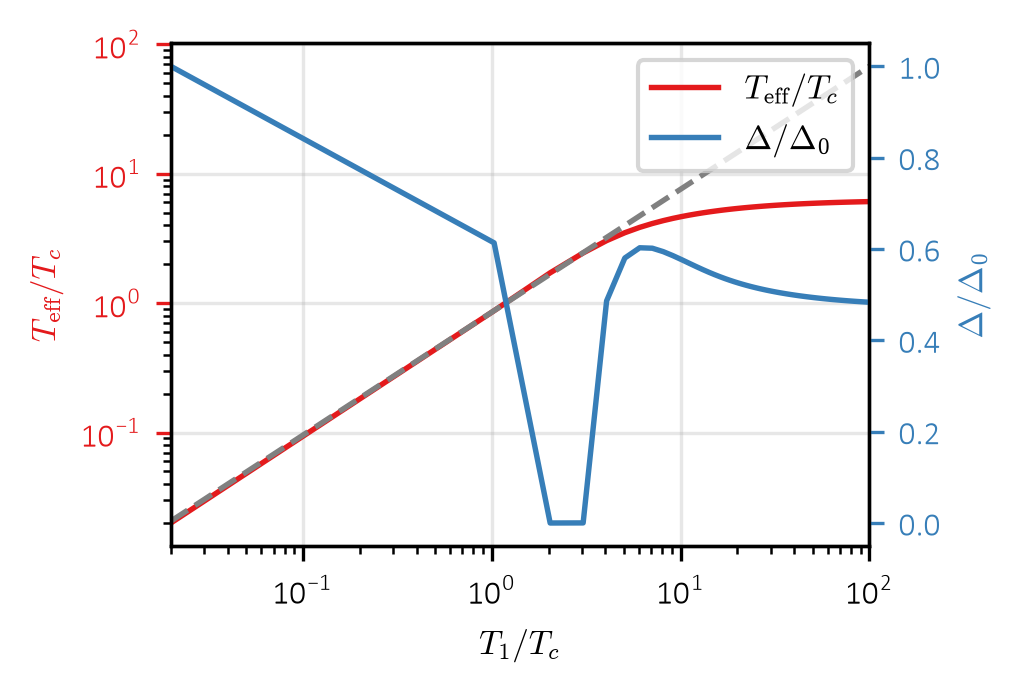

In [87]:


import numpy as np
import matplotlib.pyplot as plt
h = 0.68
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))
ax2 = ax.twinx()

l1 = ax.plot(
    t1n, te,
    color=SET1_LIST[0],
    lw=1.3,
    label=r"$T_{\mathrm{eff}}/T_c$",
)
l2 = ax2.plot(
    t1n, da,
    color=SET1_LIST[1],
    lw=1.3,
    label=r"$\Delta/\Delta_0$",
)

ax.plot(t1n, 0.85*t1n**0.95, ls="--", color="gray", lw=1.3)
ax.set_xlim(t1n[0], t1n[-1])
ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_{\mathrm{eff}}/T_c$", color=SET1_LIST[0])
ax2.set_ylabel(r"$\Delta/\Delta_0$", color=SET1_LIST[1])

ax.tick_params(axis="y", colors=SET1_LIST[0])
ax2.tick_params(axis="y", colors=SET1_LIST[1])
ax.grid(alpha=0.3)

ax.set_yscale("log")

ax.set_xscale("log")

ll = l1 + l2
ax.legend(ll, [x.get_label() for x in ll], loc=1)

plt.tight_layout()
plt.show()

Beta plots:   0%|                         0/100 [00:00<?, ?it/s]

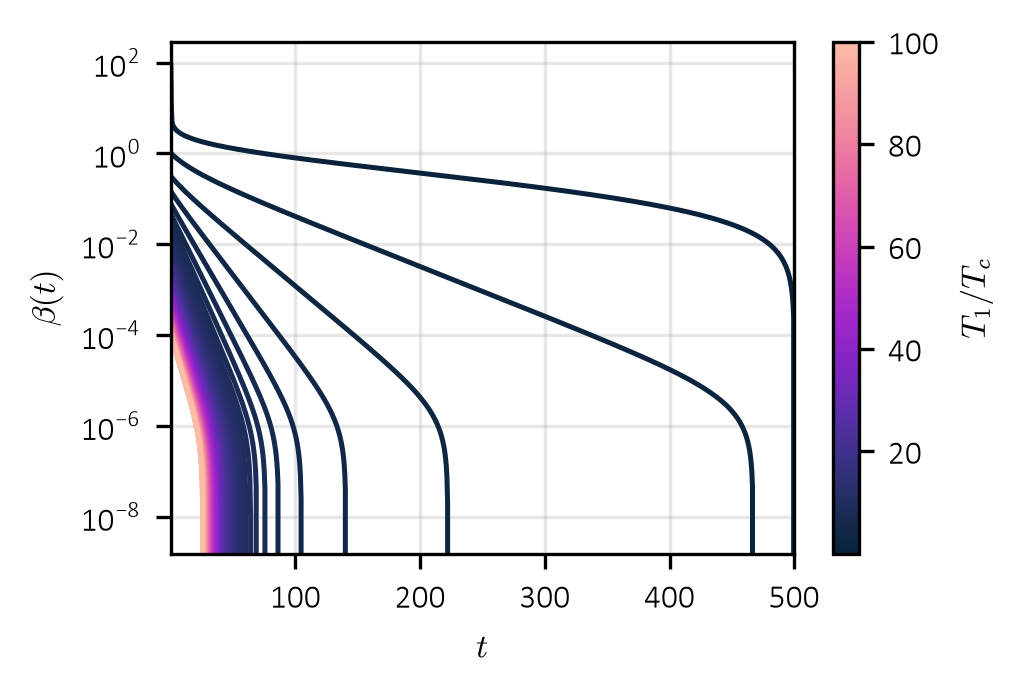

In [85]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import colormaps as cmaps


norm = Normalize(vmin=t1n.min(), vmax=t1n.max())
sm = ScalarMappable(norm=norm, cmap=cmaps.bubblegum)
sm.set_array([])

h = 0.68
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

for i, (ht, hb) in tqdm_bar(
    enumerate(bh),
    total=len(bh),
    desc="Beta plots",
):
    ax.plot(
        ht , hb - hb[-1],
        color=cmaps.bubblegum(norm(t1n[i])),
        lw=1.2,
    )

tl = np.concatenate([x for x, _ in bh])
ax.set_xlim(tl.min(), tl.max())
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\beta(t)$")
ax.grid(alpha=0.3)
ax.set_yscale("log")
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$T_1/T_c$", rotation=90, labelpad=5)

plt.tight_layout()
plt.show()